NAME: JANHAVI WELEKAR

BATCH: A3-53

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset Path: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [3]:
import os

data_dir = os.path.join(path, "brain_tumor_dataset")
print(data_dir)

/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset


In [5]:
img_size = 224
batch_size = 32

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [7]:
model1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(train_data, validation_data=val_data, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6256 - loss: 0.7872 - val_accuracy: 0.7600 - val_loss: 0.5675
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.7143 - loss: 0.5988 - val_accuracy: 0.7200 - val_loss: 0.5396
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7192 - loss: 0.5591 - val_accuracy: 0.7400 - val_loss: 0.5778
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7685 - loss: 0.5392 - val_accuracy: 0.7200 - val_loss: 0.5734
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7340 - loss: 0.5585 - val_accuracy: 0.7800 - val_loss: 0.5364
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7488 - loss: 0.5286 - val_accuracy: 0.6200 - val_loss: 0.7263
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7044 - loss: 0.5512 - val_accuracy: 0.6400 - val_loss: 0.7472
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7635 - loss: 0.5059 - val_accuracy: 0.7200 - val_loss: 0.4740
Epoch 9/

In [8]:
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history2 = model2.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.5074 - loss: 1.0121 - val_accuracy: 0.7400 - val_loss: 0.6266
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7143 - loss: 0.6308 - val_accuracy: 0.6400 - val_loss: 0.5781
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.6897 - loss: 0.5630 - val_accuracy: 0.7400 - val_loss: 0.5859
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7044 - loss: 0.6241 - val_accuracy: 0.7200 - val_loss: 0.5887
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7340 - loss: 0.5552 - val_accuracy: 0.7400 - val_loss: 0.5671
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7734 - loss: 0.5544 - val_accuracy: 0.6800 - val_loss: 0.5946
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7241 - loss: 0.5417 - val_accuracy: 0.7400 - val_loss: 0.5938
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7389 - loss: 0.5530 - val_accuracy: 0.6800 - val_loss: 0.5879
Epoch 9/

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model3 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

history3 = model3.fit(train_data, validation_data=val_data, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.6158 - loss: 0.6642 - val_accuracy: 0.9000 - val_loss: 0.3555
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7488 - loss: 0.4765 - val_accuracy: 0.8800 - val_loss: 0.2907
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8128 - loss: 0.3737 - val_accuracy: 0.9200 - val_loss: 0.2450
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8621 - loss: 0.3609 - val_accuracy: 0.9600 - val_loss: 0.1706
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8621 - loss: 0.3228 - val_accuracy: 0.9200 - val_loss: 0.2151


In [10]:
print("CNN Accuracy:", model1.evaluate(val_data)[1])
print("Dropout CNN Accuracy:", model2.evaluate(val_data)[1])
print("Transfer Learning Accuracy:", model3.evaluate(val_data)[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 423ms/step - accuracy: 0.8200 - loss: 0.4966
CNN Accuracy: 0.8199999928474426
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.7800 - loss: 0.4836
Dropout CNN Accuracy: 0.7799999713897705
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 681ms/step - accuracy: 0.9600 - loss: 0.1783
Transfer Learning Accuracy: 0.9599999785423279


In [11]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model3.predict(img_array)

    if prediction[0][0] > 0.5:
        print("Tumor Detected")
    else:
        print("No Tumor")

# Example (use actual file path)
sample_path = os.path.join(data_dir, "yes", os.listdir(os.path.join(data_dir, "yes"))[0])
predict_image(sample_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
No Tumor


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [13]:
# True labels
y_true = val_data.classes

# Predictions
y_pred_prob = model3.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Flatten
y_pred = y_pred.flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step


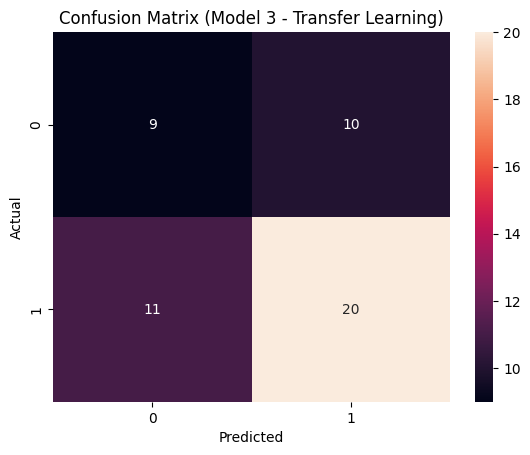

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Model 3 - Transfer Learning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.45      0.47      0.46        19
           1       0.67      0.65      0.66        31

    accuracy                           0.58        50
   macro avg       0.56      0.56      0.56        50
weighted avg       0.58      0.58      0.58        50



In [16]:
acc1 = history1.history['val_accuracy'][-1]
acc2 = history2.history['val_accuracy'][-1]
acc3 = history3.history['val_accuracy'][-1]

models = ['CNN', 'CNN + Dropout', 'Transfer Learning']
accuracies = [acc1, acc2, acc3]

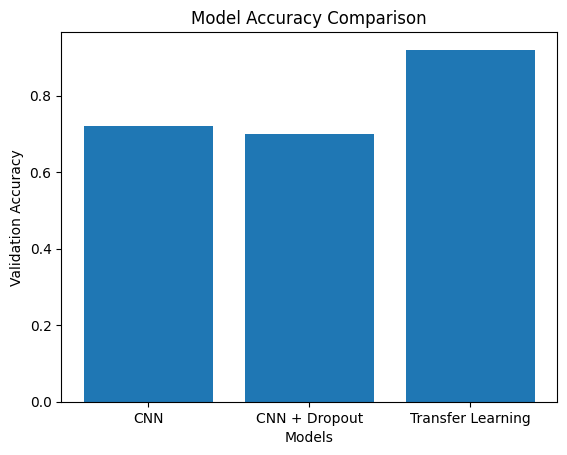

In [17]:
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Validation Accuracy")
plt.show()

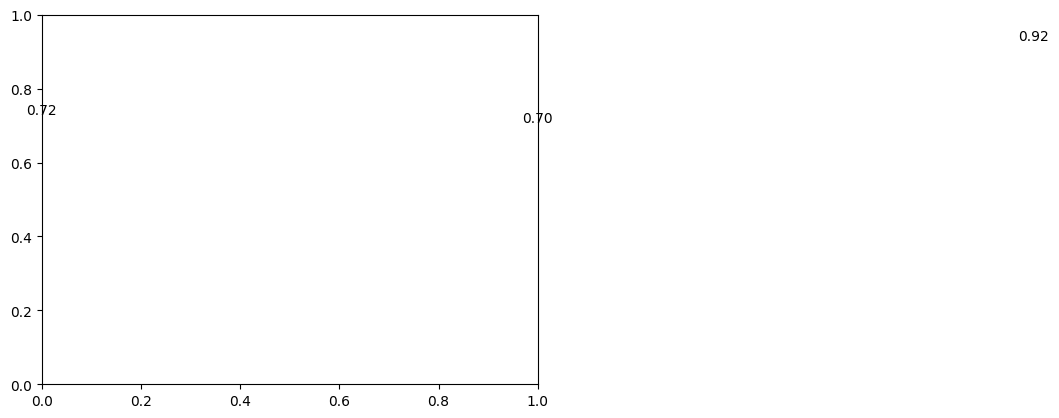

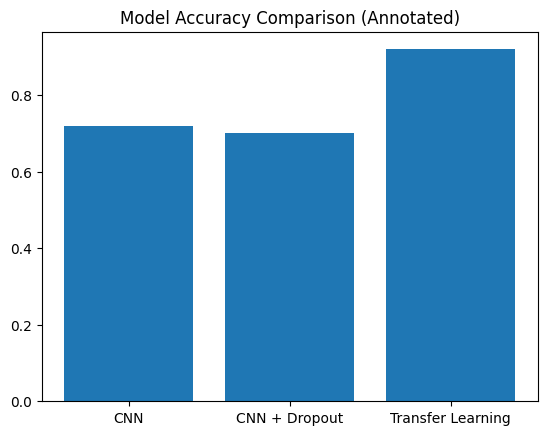

In [18]:
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison (Annotated)")
plt.show()